# Plotting Figure 8 (top half)

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

df = pd.read_csv('site_params.csv')

x = df['SQRT(D84/D16)'].values
a_vals = df['A'].values
b_vals = df['B'].values
ks_vals = df['Ks'].values
kw_vals = df['Kw'].values
bounds = df['bound_range'].values
sites = df['site'].values

### Parameter Fits

In [52]:
# determine colors for each site
site_colors = {
    'Erlenbach': 'crimson',   # red
    'Flume': 'dodgerblue',       # blue
    'La Jara': '#2ca02c'      # green
}

colors = [site_colors[s] for s in sites]

# fit functions
def linear(x, m, c):
    return m * x + c

# linear fit to A vs sqrt(D84/D16)
a_params, _ = curve_fit(linear, x, a_vals)
a_m_fit, a_c_fit = a_params
a_x_line = np.linspace(min(x), max(x), 300)
a_y_line = linear(a_x_line, a_m_fit, a_c_fit)
# R²
a_pred = linear(x, a_m_fit, a_c_fit)
r2_a = r2_score(a_vals, a_pred)

# linear fit to B vs sqrt(D84/D16)
b_params, _ = curve_fit(linear, x, b_vals)
b_m_fit, b_c_fit = b_params
b_x_line = np.linspace(min(x), max(x), 300)
b_y_line = linear(b_x_line, b_m_fit, b_c_fit)
# R²
b_pred = linear(x, b_m_fit, b_c_fit)
r2_b = r2_score(b_vals, b_pred)

# fit linear to Ks vs sqrt(D84/D16)
ks_m, ks_c = np.polyfit(x, ks_vals, 1)
ks_x_line = np.linspace(min(x), max(x), 300)
ks_y_line = linear(ks_x_line, ks_m, ks_c)
pred = linear(x, ks_m, ks_c)
r2_ks = r2_score(ks_vals, pred)

# fit linear to Kw vs sqrt(D84/D16)
kw_m, kw_c = np.polyfit(x, kw_vals, 1)
kw_x_line = np.linspace(min(x), max(x), 300)
kw_y_line = linear(kw_x_line, kw_m, kw_c)
pred = linear(x, kw_m, kw_c)   
r2_kw = r2_score(kw_vals, pred)

# fit linear to bound range vs sqrt(D84/D16)
bound_m, bound_c = np.polyfit(x, bounds, 1)
bound_x_line = np.linspace(min(x), max(x), 300)
bound_y_line = linear(bound_x_line, bound_m, bound_c)
pred = linear(x, bound_m, bound_c)
r2_bound = r2_score(bounds, pred)

# print results
print(f"A fit: A={a_m_fit:.3f}, b={a_c_fit:.3f}, R²={r2_a:.3f}")
print(f"B fit: A={b_m_fit:.3f}, b={b_c_fit:.3f}, R²={r2_b:.3f}")
print(f"Ks fit: m={ks_m:.3f}, c={ks_c:.3f}, R²={r2_ks:.3f}")
print(f"Kw fit: m={kw_m:.3f}, c={kw_c:.3f}, R²={r2_kw:.3f}")
print(f"Bound range fit: m={bound_m:.3f}, c={bound_c:.3f}, R²={r2_bound:.3f}")

A fit: A=-0.104, b=0.346, R²=0.409
B fit: A=-2.023, b=10.653, R²=0.667
Ks fit: m=-24.469, c=93.595, R²=0.970
Kw fit: m=-2.392, c=10.343, R²=0.386
Bound range fit: m=0.116, c=-0.178, R²=0.998


## Equilibrium Function

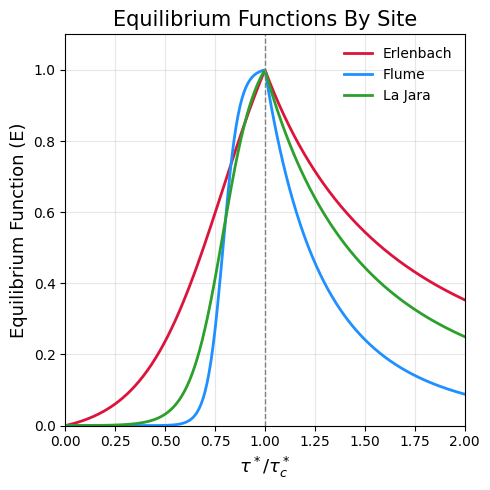

In [ ]:
site_params = {
    'Erlenbach': {'ks': 5.0,  'kw': 1.5},
    'Flume':     {'ks': 25.0, 'kw': 3.5},
    'La Jara':   {'ks': 12.0, 'kw': 2.0}
}

tau_c_min = 0.03
tau_c_max = 1.0
xs = 0.79 # sigmoid midpoint
tc_vals = np.linspace(0, 5, 1000) # τ*/τ*c range


fig, ax = plt.subplots(figsize=(5, 5))
for site, params in site_params.items():
    ks = params['ks']
    kw = params['kw']
    tau_equil = []
    for tc in tc_vals:
        # sigmoid function for strengthening (t/tau_c* < 1)
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoid_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (
                (sigmoid_tc - sigmoid_0)
                / (sigmoid_1 - sigmoid_0))
            E = sigmoid

        # exponential function for weakening (t/tau_c* > 1)
        else:
            E = ((tc ** (-kw)))
        tau_equil.append(E)

    # plot
    ax.plot(tc_vals, tau_equil, linewidth=2, color=site_colors[site], label=site)
ax.axvline(1, linestyle='--', color='gray', linewidth=1)
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.1)
ax.set_xlabel(r'$\tau^* / \tau_c^*$', fontsize=13)
ax.set_ylabel(r'Equilibrium Function (E)', fontsize=13)
ax.set_title(r'Equilibrium Functions By Site', fontsize=15)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Parameter Relationships

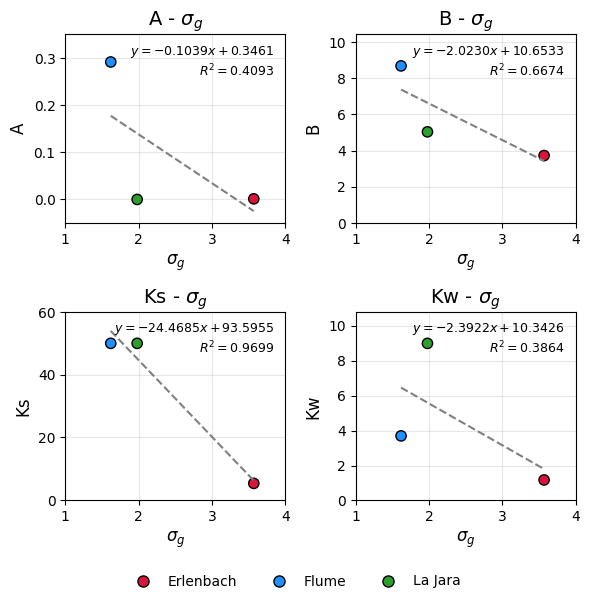

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
# set grid behind all plot elements
for ax in axes.flat:
    ax.set_axisbelow(True)

# (A) A vs sigma_g
ax = axes[0, 0]
ax.plot(a_x_line, a_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, a_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(-0.05, max(a_vals) * 1.2)
ax.set_title(r'A - $\sigma_g$', fontsize=14)
ax.set_xlabel(r'$\sigma_g$', fontsize=12)
ax.set_ylabel('A', fontsize=12)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {a_m_fit:.4f}x + {a_c_fit:.4f}$' '\n' rf'$R^2 = {r2_a:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (B) B vs sigma_g
ax = axes[0, 1]
ax.plot(b_x_line, b_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, b_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(0, max(b_vals) * 1.2)
ax.set_title(r'B - $\sigma_g$', fontsize=14)
ax.set_xlabel(r'$\sigma_g$', fontsize=12)
ax.set_ylabel('B', fontsize=12)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {b_m_fit:.4f}x + {b_c_fit:.4f}$' '\n' rf'$R^2 = {r2_b:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (C) Ks vs sigma_g
ax = axes[1, 0]
ax.plot(ks_x_line, ks_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, ks_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(-0.1, max(ks_vals) * 1.2)
ax.set_title(r'Ks - $\sigma_g$', fontsize=14)
ax.set_xlabel(r'$\sigma_g$', fontsize=12)
ax.set_ylabel('Ks', fontsize=12)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {ks_m:.4f}x + {ks_c:.4f}$' '\n' rf'$R^2 = {r2_ks:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (D) Kw vs sigma_g
ax = axes[1, 1]
ax.plot(kw_x_line, kw_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, kw_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(0, max(kw_vals) * 1.2)
ax.set_title(r'Kw - $\sigma_g$', fontsize=14)
ax.set_xlabel(r'$\sigma_g$', fontsize=12)
ax.set_ylabel('Kw', fontsize=12)
ax.grid(True, alpha=0.3)

eq_text = (rf'$y = {kw_m:.4f}x + {kw_c:.4f}$' '\n' rf'$R^2 = {r2_kw:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# legend
handles = []
for site, color in site_colors.items():
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=site, markeredgecolor='black', markeredgewidth=1))

fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Final

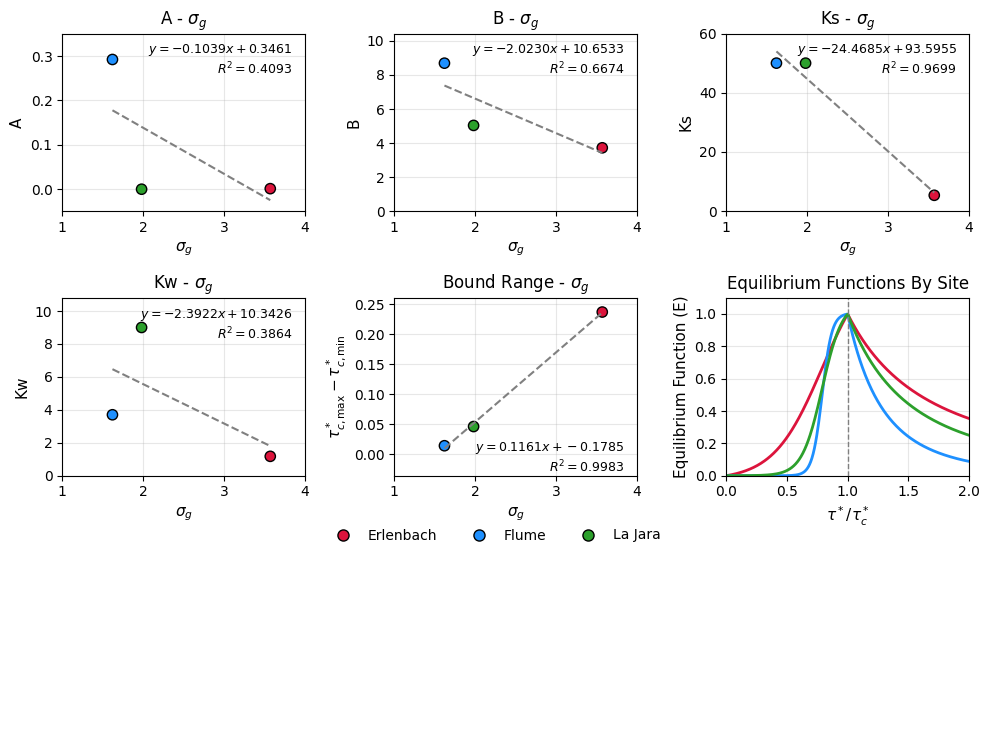

In [81]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()

# set grid behind all plot elements
for ax in axes:
    ax.set_axisbelow(True)

# (1) A vs sigma_g
ax = axes[0]
ax.plot(a_x_line, a_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, a_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(-0.05, max(a_vals) * 1.2)
ax.set_title(r'A - $\sigma_g$', fontsize=12)
ax.set_xlabel(r'$\sigma_g$', fontsize=11)
ax.set_ylabel('A', fontsize=11)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {a_m_fit:.4f}x + {a_c_fit:.4f}$' '\n' rf'$R^2 = {r2_a:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (2) B vs sigma_g
ax = axes[1]
ax.plot(b_x_line, b_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, b_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(0, max(b_vals) * 1.2)
ax.set_title(r'B - $\sigma_g$', fontsize=12)
ax.set_xlabel(r'$\sigma_g$', fontsize=11)
ax.set_ylabel('B', fontsize=11)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {b_m_fit:.4f}x + {b_c_fit:.4f}$' '\n' rf'$R^2 = {r2_b:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (3) Ks vs sigma_g
ax = axes[2]
ax.plot(ks_x_line, ks_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, ks_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(-0.1, max(ks_vals) * 1.2)
ax.set_title(r'Ks - $\sigma_g$', fontsize=12)
ax.set_xlabel(r'$\sigma_g$', fontsize=11)
ax.set_ylabel('Ks', fontsize=11)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {ks_m:.4f}x + {ks_c:.4f}$' '\n' rf'$R^2 = {r2_ks:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (4) Kw vs sigma_g
ax = axes[3]
ax.plot(kw_x_line, kw_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, kw_vals, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(0, max(kw_vals) * 1.2)
ax.set_title(r'Kw - $\sigma_g$', fontsize=12)
ax.set_xlabel(r'$\sigma_g$', fontsize=11)
ax.set_ylabel('Kw', fontsize=11)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {kw_m:.4f}x + {kw_c:.4f}$' '\n' rf'$R^2 = {r2_kw:.4f}$')
ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# (5) Bound range regression
ax = axes[4]
ax.plot(bound_x_line, bound_y_line, color='gray', linewidth=1.5, linestyle='--')
ax.scatter(x, bounds, s=55, c=colors, edgecolors='black', linewidth=1)
ax.set_xlim(1, 4)
ax.set_ylim(min(bounds) - 0.05, max(bounds) * 1.1)
ax.set_title(r'Bound Range - $\sigma_g$', fontsize=12)
ax.set_xlabel(r'$\sigma_g$', fontsize=11)
ax.set_ylabel(r'$\tau_{c,\mathrm{max}}^* - \tau_{c,\mathrm{min}}^*$', fontsize=11)
ax.grid(True, alpha=0.3)
eq_text = (rf'$y = {bound_m:.4f}x + {bound_c:.4f}$' '\n' rf'$R^2 = {r2_bound:.4f}$')
ax.text(0.95, 0.2, eq_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'),
        ha='right', va='top')

# turn off unused panels
for ax in axes[6:]:
    ax.axis('off')

# (6) Equilibrium functions by site
site_params = {
    'Erlenbach': {'ks': 5.0,  'kw': 1.5},
    'Flume':     {'ks': 25.0, 'kw': 3.5},
    'La Jara':   {'ks': 12.0, 'kw': 2.0}
}

xs = 0.79
tc_vals = np.linspace(0, 5, 1000)

ax = axes[5]
for site, params in site_params.items():
    ks = params['ks']
    kw = params['kw']
    tau_equil = []

    for tc in tc_vals:
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoid_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (sigmoid_tc - sigmoid_0) / (sigmoid_1 - sigmoid_0)
            E = sigmoid
        else:
            E = tc ** (-kw)

        tau_equil.append(E)

    ax.plot(tc_vals, tau_equil, linewidth=2, color=site_colors[site], label=site)
ax.axvline(1, linestyle='--', color='gray', linewidth=1)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.1)
ax.set_xlabel(r'$\tau^* / \tau_c^*$', fontsize=11)
ax.set_ylabel(r'Equilibrium Function (E)', fontsize=11)
ax.set_title(r'Equilibrium Functions By Site', fontsize=12)
ax.grid(True, alpha=0.3)

# shared legend for site colors
handles = []
for site, color in site_colors.items():
    handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=8,
                   markeredgecolor='black', markeredgewidth=1, label=site)
    )

fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.3))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('param_relationships.png', dpi=500, bbox_inches='tight')
plt.show()